In [12]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/babeczka"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection/babeczka


In [13]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "test" / "images"
test_labels = root / "test" / "labels"

valid_images = root / "valid" / "images"
valid_labels = root / "valid" / "labels"

print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection/babeczka/train/images
Train labels path: Sign Language Detection/babeczka/train/labels


In [14]:
for p in [train_images, train_labels]:
    if not p.exists():
        print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))

Train images: 230


Showing sample: hello_2cdf95c0-7a66-11ed-a1fd-1e08bc6ed8a6_jpg.rf.922a56f4e49598a43d24e38ba503740f.jpg


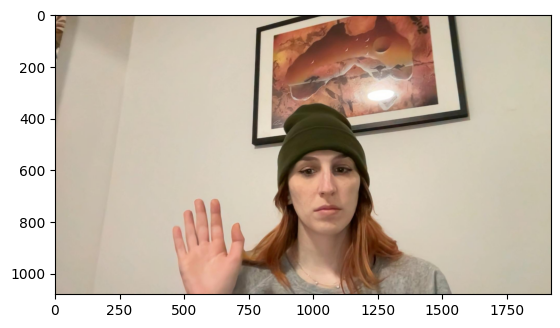

In [15]:
import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")
    print("Showing sample:", sample_img.name)
    plt.imshow(plt.imread(sample_img))
else:
    print("No images found in train/images.")

In [16]:
IMG_SIZE = 400

In [18]:
from pathlib import Path
import yaml

data_path = root / "data.yaml"

with data_path.open("r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

CLASSES = data["names"]          # list of class names
amount = data.get("nc", len(CLASSES))
print("names:", CLASSES)

names: ['hello', 'iloveyou', 'no', 'yes']


In [35]:
NUMBER_OF_CLASSES = len(CLASSES)
NUMBER_OF_CLASSES

4

In [19]:
import cv2
import numpy as np

def crop_hand(image_path, model):
    # 1. Przygotuj obraz
    original_img = cv2.imread(image_path)
    img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    input_tensor = np.expand_dims(img_resized, axis=0)

    # 2. Predykcja ramki
    box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
    
    # 3. Przelicz na piksele
    h_orig, w_orig, _ = original_img.shape
    x = int(box[0] * w_orig)
    y = int(box[1] * h_orig)
    w = int(box[2] * w_orig)
    h = int(box[3] * h_orig)

    # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
    x = max(0, x)
    y = max(0, y)
    
    # 4. Wycięcie (Crop)
    # Dodajemy mały margines (padding), żeby nie uciąć palców
    padding = 20
    crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
    
    return crop, (x, y, w, h)

In [20]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

def load_data_from_labels(img_dir, label_dir, target_size=(IMG_SIZE, IMG_SIZE), padding=20):
    """
    Wczytuje obrazy, wycina dłonie na podstawie etykiet .txt (Ground Truth)
    i przygotowuje je do treningu klasyfikatora.
    """
    images = []
    labels = []
    
    img_files = sorted(list(img_dir.glob("*.*"))) # Szukamy jpg, png, etc.
    
    print(f"Przetwarzanie {len(img_files)} obrazów na podstawie etykiet...")

    for i, img_path in enumerate(img_files):
        # 1. Sprawdzenie czy istnieje plik etykiety
        # Szukamy pliku o tej samej nazwie w folderze labels
        label_path = label_dir / (img_path.stem + ".txt")
        
        if not label_path.exists():
            # Jeśli nie ma etykiety, nie wiemy gdzie jest dłoń -> pomijamy
            continue

        # 2. Odczytanie współrzędnych z pliku
        with open(label_path, 'r') as f:
            line = f.readline().split()
            if not line: continue
            
            # Format YOLO: class_id center_x center_y width height (znormalizowane 0-1)
            class_id = int(line[0])
            cx, cy, w_norm, h_norm = map(float, line[1:])

        # 3. Wczytanie obrazu
        img = cv2.imread(str(img_path))
        if img is None: continue
        
        # Konwersja na RGB (ważne dla treningu!)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img, _ = img.shape

        # 4. Przeliczenie współrzędnych (YOLO -> Piksele)
        # Obliczamy lewy górny róg
        w_px = int(w_norm * w_img)
        h_px = int(h_norm * h_img)
        x_px = int((cx * w_img) - (w_px / 2))
        y_px = int((cy * h_img) - (h_px / 2))

        # 5. Dodanie marginesu (Padding) i zabezpieczenie krawędzi
        # Chcemy wyciąć dłoń z lekkim zapasem, żeby nie uciąć palców
        x = max(0, x_px - padding)
        y = max(0, y_px - padding)
        w = min(w_img - x, w_px + 2 * padding)
        h = min(h_img - y, h_px + 2 * padding)

        # 6. Wycięcie (Crop)
        hand_crop = img[y : y + h, x : x + w]

        # Zabezpieczenie przed pustym wycinkiem (gdyby etykieta była błędna)
        if hand_crop.size == 0:
            continue

        # 7. Resize do formatu wejściowego sieci (np. 224x224)
        try:
            hand_crop_resized = cv2.resize(hand_crop, target_size)
        except Exception as e:
            print(f"Błąd resize dla {img_path.name}: {e}")
            continue

        images.append(hand_crop_resized)
        labels.append(class_id)
            
        # Pokaż postęp co 100 zdjęć
        if i % 100 == 0:
            print(f"Przetworzono {i}/{len(img_files)}")

    print(f"Zakończono. Załadowano {len(images)} poprawnych wycinków.")
    
    # Normalizacja i One-Hot Encoding
    return np.array(images) / 255.0, to_categorical(np.array(labels), num_classes=NUMBER_OF_CLASSES)

In [21]:
X_train, y_train = load_data_from_labels(train_images, train_labels)

Przetwarzanie 230 obrazów na podstawie etykiet...
Przetworzono 0/230
Przetworzono 100/230
Przetworzono 200/230
Zakończono. Załadowano 230 poprawnych wycinków.


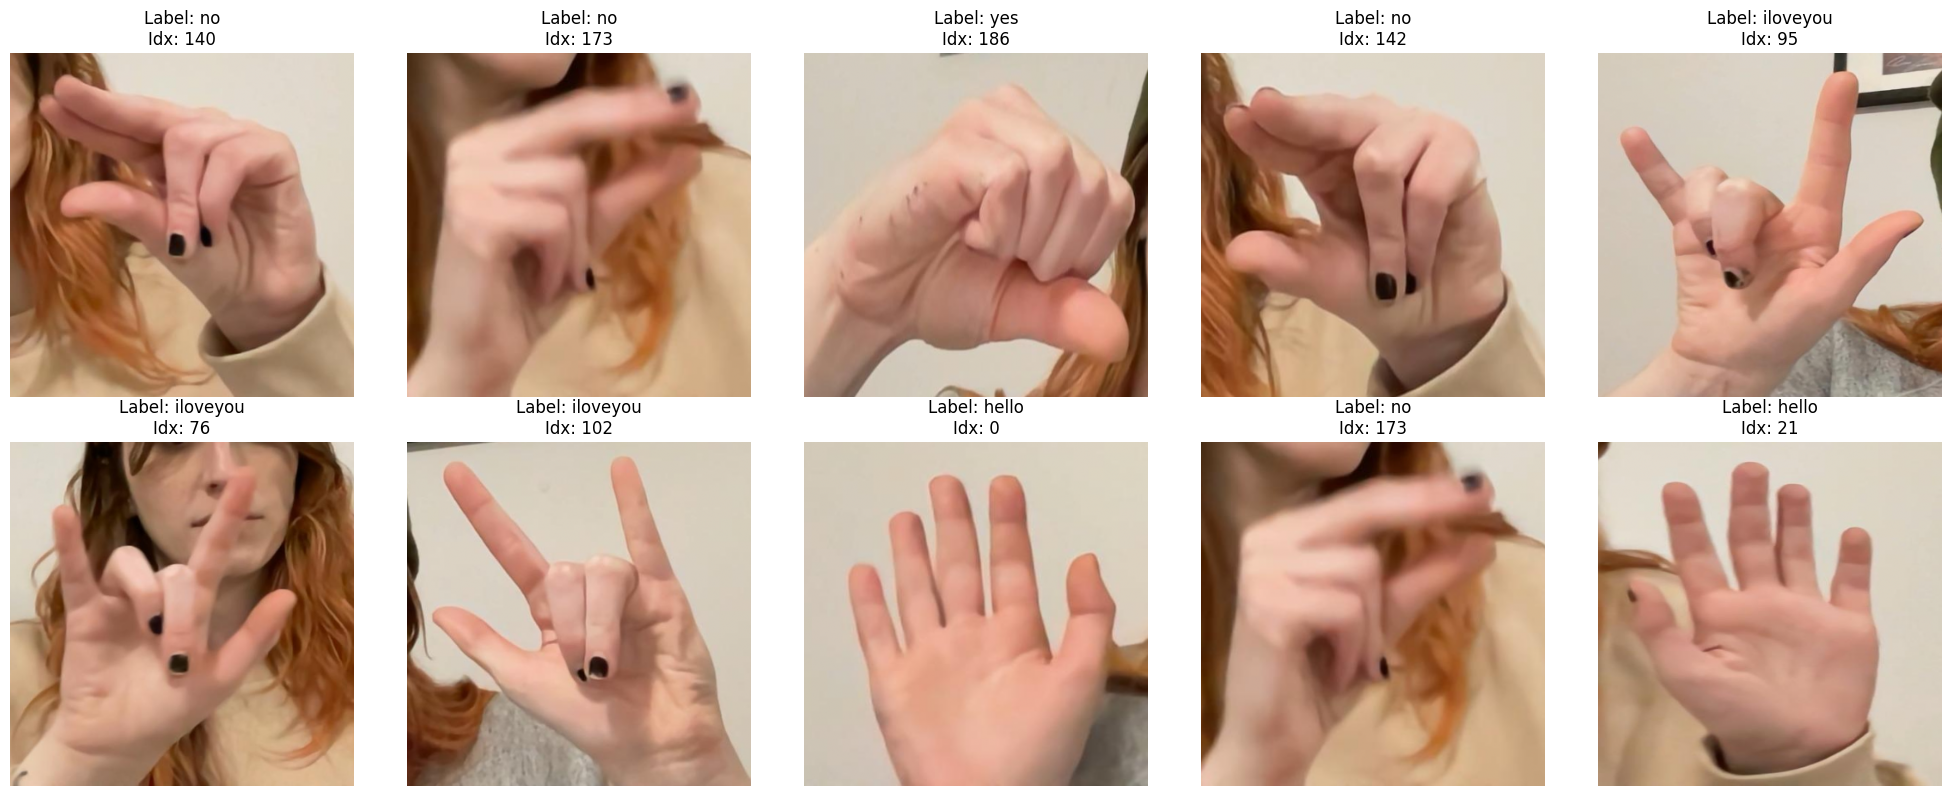

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_crops(images, labels, num_samples=10):
    plt.figure(figsize=(20, 8))
    
    # Losujemy indeksy, żeby nie oglądać tylko pierwszych zdjęć
    indices = np.random.randint(0, len(images), num_samples)
    
    for i, idx in enumerate(indices):
        # Pobieramy obraz i etykietę
        img = images[idx]
        label_onehot = labels[idx]
        
        # Dekodowanie One-Hot (np. [0, 0, 1, 0] -> 2)
        class_idx = np.argmax(label_onehot)
        class_name = CLASSES[class_idx] if class_idx < len(CLASSES) else f"Class {class_idx}"
        
        plt.subplot(2, 5, i + 1) # Układ 2 rzędy po 5 zdjęć
        plt.imshow(img)
        plt.title(f"Label: {class_name}\nIdx: {idx}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()


visualize_crops(X_train, y_train)


In [23]:
X_train.shape

(230, 400, 400, 3)

In [24]:
X_test, y_test = load_data_from_labels(valid_images, valid_labels)

Przetwarzanie 76 obrazów na podstawie etykiet...
Przetworzono 0/76
Zakończono. Załadowano 76 poprawnych wycinków.


In [25]:
from keras import backend as K

print(K.image_data_format())

channels_last


In [42]:
from keras import layers, models, regularizers

# def residual_block(x, filters, kernel_size=3, stride=1):
#     shortcut = x
    
#     # --- Główna ścieżka ---
#     # 1. Konwolucja
#     x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
#     # 2. Batch Norm (KLUCZ DO SUKCESU)
#     x = layers.BatchNormalization()(x)
#     # 3. Aktywacja
#     x = layers.Activation('relu')(x)
    
#     # 4. Druga konwolucja
#     x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
#     x = layers.BatchNormalization()(x)
    
#     # --- Obsługa skrótu (Shortcut) ---
#     # Jeśli zmieniamy wymiary (stride > 1) lub liczbę filtrów, musimy dopasować skrót
#     if x.shape[-1] != shortcut.shape[-1] or stride > 1:
#         shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', use_bias=False)(shortcut)
#         shortcut = layers.BatchNormalization()(shortcut)
        
#     # --- Połączenie ---
#     x = layers.Add()([x, shortcut])
#     x = layers.Activation('relu')(x)
#     return x

# def build_improved_resnet(img_size, num_classes):
#     inputs = layers.Input(shape=(img_size, img_size, 3))
    
#     # Wejściowa warstwa - agresywniejsza (stride=2) by zmniejszyć obraz na start
#     x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
#     # Bloki rezydualne (Coraz więcej filtrów)
#     x = residual_block(x, 64)
#     x = residual_block(x, 64)
    
#     x = residual_block(x, 128, stride=2) # stride=2 zmniejsza obraz o połowę
#     x = residual_block(x, 128)
    
#     x = residual_block(x, 256, stride=2)
#     x = residual_block(x, 256)
    
#     # Zakończenie
#     x = layers.GlobalAveragePooling2D()(x)
    
#     x = layers.Dense(256, activation='relu')(x)
#     x = layers.Dropout(0.5)(x) # Ważne przy małym datasecie!
    
#     outputs = layers.Dense(num_classes, activation='softmax')(x)
    
#     model = models.Model(inputs, outputs)
#     return model

# # Budowa modelu
# model = build_improved_resnet(IMG_SIZE, NUMBER_OF_CLASSES)
# model.summary()

# dziala!
from tensorflow.keras import layers, models

model = models.Sequential([
    # Pierwsza warstwa splotowa - wyciąga krawędzie i proste wzory
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Druga warstwa - bardziej złożone kształty dłoni
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Trzecia warstwa
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Spłaszczenie danych do warstw gęstych (klasyfikatora)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Zapobiega przeuczeniu
    layers.Dense(NUMBER_OF_CLASSES, activation='softmax') # 5 wyjść (dla każdej klasy znaku)
])

model.summary()


# model = models.Sequential([
#     # --- Blok 1 ---
#     # Input
#     layers.Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
#     layers.BatchNormalization(), # Stabilizuje naukę
#     layers.Activation('relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     # --- Blok 2 ---
#     layers.Conv2D(64, (3, 3), padding='same'),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     # --- Blok 3 ---
#     layers.Conv2D(128, (3, 3), padding='same'),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D((2, 2)),
    
#     # --- Klasyfikator ---
#     layers.Flatten(),  # Wracamy do Flatten - sieć potrzebuje tych danych
    
#     layers.Dense(256, activation='relu'), # Zwiększamy nieco pojemność warstwy gęstej
#     layers.BatchNormalization(), # To pomoże uniknąć przeuczenia lepiej niż samo zmniejszanie sieci
#     layers.Dropout(0.5),         # Jedyny, ale konkretny Dropout - odrzuca 50% neuronów w każdej epoce
    
#     layers.Dense(NUMBER_OF_CLASSES, activation='softmax')
# ])

# model.summary()

# def build_separable_cnn(img_size, num_classes):
#     inputs = layers.Input(shape=(img_size, img_size, 3))
    
#     # Wejście
#     x = layers.Conv2D(32, (3, 3), strides=2, padding='same')(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)

#     # Bloki Separowalne (Są lżejsze i mądrzejsze)
#     for filters in [64, 128, 256]:
#         # Aktywacja przed splotem (pre-activation style)
#         x = layers.Activation('relu')(x)
#         x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
#         x = layers.BatchNormalization()(x)

#         x = layers.Activation('relu')(x)
#         x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
#         x = layers.BatchNormalization()(x)

#         x = layers.MaxPooling2D((2, 2))(x)
#         x = layers.Dropout(0.2)(x) # Mały dropout w każdym bloku

#     # Klasyfikator
#     x = layers.GlobalAveragePooling2D()(x)
    
#     x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dropout(0.5)(x)
    
#     outputs = layers.Dense(num_classes, activation='softmax')(x)
    
#     return models.Model(inputs, outputs)

# model = build_separable_cnn(IMG_SIZE, NUMBER_OF_CLASSES)
# model.summary()


/mnt/d/Magisterka/Semestr 3/Uczenie Glebokie L/hand-sign-recognition/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 398, 398, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 199, 199, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 197, 197, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 294912)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    37,748,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,842,628 (144.36 MB)

 Trainable params: 37,842,628 (144.36 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [44]:
# Callbacks - Zatrzymanie treningu, gdy model przestanie się uczyć
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001),
     # Zapisz model tylko, gdy wynik na walidacji się poprawi
    tf.keras.callbacks.ModelCheckpoint(
        'gesture_classifier.keras', 
        save_best_only=True, 
        monitor='val_loss'
    ),
]

In [45]:
# Start treningu
history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 376ms/step - accuracy: 0.3000 - loss: 3.5327 - val_accuracy: 0.2895 - val_loss: 1.4003 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.3696 - loss: 1.3617 - val_accuracy: 0.2368 - val_loss: 1.3370 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.6261 - loss: 0.9060 - val_accuracy: 0.6053 - val_loss: 1.2617 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.7913 - loss: 0.6545 - val_accuracy: 0.8421 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.9217 - loss: 0.2722 - val_accuracy: 0.8421 - val_loss: 0.4751 - learning_rate: 0.0010
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.9565 - loss: 0.1293 - val_accuracy: 0.8816 - val_loss: 0.3591 - learning_rate: 0.0010
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9696 - loss: 0.1374 - v

In [46]:
score = model.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9737 - loss: 0.1861 


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step


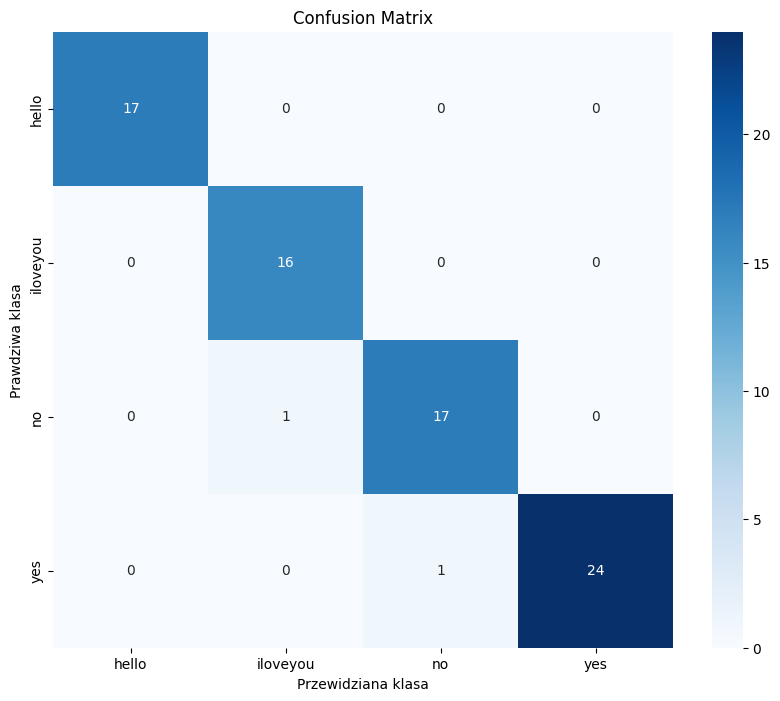

              precision    recall  f1-score   support

       hello       1.00      1.00      1.00        17
    iloveyou       0.94      1.00      0.97        16
          no       0.94      0.94      0.94        18
         yes       1.00      0.96      0.98        25

    accuracy                           0.97        76
   macro avg       0.97      0.98      0.97        76
weighted avg       0.97      0.97      0.97        76



In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Predykcja na zbiorze testowym
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Macierz pomyłek
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Wykres
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.title('Confusion Matrix')
plt.show()

# 4. Raport tekstowy
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predykcja: iloveyou z pewnością 100.00%


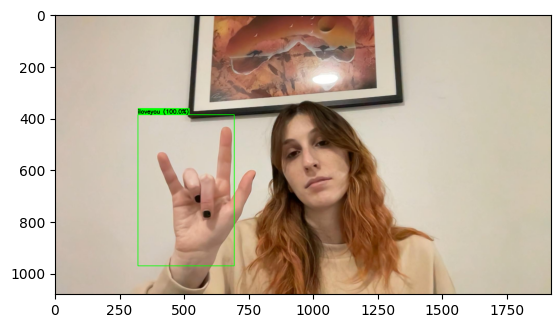

In [50]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_full_pipeline(image_path, detector_model, classifier_model, classes_list):
    img_bgr = cv2.imread(image_path)
    hand_crop, coords = crop_hand(image_path, detector_model)
    x_pad = coords[0]
    y_pad = coords[1]
    w_pad = coords[2]
    h_pad = coords[3]

    # Zabezpieczenie przed pustym wycinkiem (gdyby detektor zawiódł)
    if hand_crop.size == 0:
        print("Nie udało się wyciąć dłoni (błąd detektora).")
        return

    # =========================================================
    # KROK 2: KLASYFIKACJA (Jaki to gest?)
    # =========================================================

    # Preprocessing dla klasyfikatora
    img_cls = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_cls_batch = np.expand_dims(img_cls, axis=0)

    # Predykcja gestu
    predictions = classifier_model.predict(img_cls_batch, verbose=0)[0]
    class_idx = np.argmax(predictions)       # Indeks najwyższego wyniku
    confidence = predictions[class_idx]      # Pewność (0.0 - 1.0)
    
    predicted_label = classes_list[class_idx]
    
    print(f"Predykcja: {predicted_label} z pewnością {confidence*100:.2f}%")

    # =========================================================
    # KROK 3: WIZUALIZACJA
    # =========================================================
    
    # Kolor ramki zależny od pewności (Zielony = pewny, Żółty = niepewny)
    color = (0, 255, 0) if confidence > 0.7 else (0, 255, 255)

    # Rysujemy ramkę na ORYGINALNYM obrazie BGR
    cv2.rectangle(img_bgr, (x_pad, y_pad), (x_pad + w_pad, y_pad + h_pad), color, 2)

    # Przygotowanie tekstu: "I love You (98%)"
    text = f"{predicted_label} ({confidence*100:.1f}%)"
    
    # Tło pod napisem (dla czytelności)
    (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(img_bgr, (x_pad, y_pad - 25), (x_pad + text_w, y_pad), color, -1)
    
    # Napis
    cv2.putText(img_bgr, text, (x_pad, y_pad - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    # Pokazanie wyniku
    cropped_img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(cropped_img_rgb)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

# -----------------------------------------------------------
# PRZYKŁAD UŻYCIA
# -----------------------------------------------------------

detector = tf.keras.models.load_model('hand_detector_best.keras')
classifier = tf.keras.models.load_model('gesture_classifier.keras')

# Uruchomienie funkcji
predict_full_pipeline("Sign Language Detection/babeczka/test/images/iloveyou_1f4c00c4-7679-11ed-bb1e-1e08bc6ed8a6_jpg.rf.e6b72a4127ff5544f3bd78317ca11b0e.jpg", detector, classifier, CLASSES)